In [1]:
import papermill as pm
import subprocess, os, time
from joblib import Parallel, delayed

In [2]:
py_nb = 'WaterfowlHabitatSinglefips_recalc_v2.ipynb'
pm.inspect_notebook(py_nb)

{'aoi': {'name': 'aoi',
  'inferred_type_name': 'None',
  'default': "'28001'",
  'help': ''},
 'nwiurl': {'name': 'nwiurl',
  'inferred_type_name': 'None',
  'default': 'r"azure://abdu/nwi/**/*.parquet"',
  'help': ''},
 'wetattrfld': {'name': 'wetattrfld',
  'inferred_type_name': 'None',
  'default': "'ATTRIBUTE'",
  'help': ''},
 'waterurl': {'name': 'waterurl',
  'inferred_type_name': 'None',
  'default': 'True',
  'help': ''},
 'politicalbndry': {'name': 'politicalbndry',
  'inferred_type_name': 'None',
  'default': "r'azure://abdu/uscounties.parquet'",
  'help': ''},
 'pid_fld': {'name': 'pid_fld',
  'inferred_type_name': 'None',
  'default': "'FIPS'",
  'help': ''},
 'hucsurl': {'name': 'hucsurl',
  'inferred_type_name': 'None',
  'default': "r'azure://abdu/huc/**/*.parquet'",
  'help': ''},
 'hucidfld': {'name': 'hucidfld',
  'inferred_type_name': 'None',
  'default': "'huc12'",
  'help': ''},
 'crossWalk_json': {'name': 'crossWalk_json',
  'inferred_type_name': 'None',
  'defa

In [3]:
# import duckdb
# con = duckdb.connect()
# con.install_extension("spatial")
# con.load_extension("spatial")
# con.install_extension("azure")
# con.load_extension("azure")

In [4]:
# nwiurl = r"D:\ABDUBounds\ABDU_Canada_Data\parquet\abdu_cn_east_wet_wkb.parquet"
nwiurl = r"D:\ABDUBounds\ABDU_Canada_Data\parquet\abdu_cn_east_weth2o.parquet"
hucsurl = r"D:\ABDUBounds\ABDU_Canada_Data\parquet\abdu_cn_east_wsheds.parquet"
# waterurl = r"D:\ABDUBounds\ABDU_Canada_Data\parquet\old_abdu_openH2o_cn_east_wkb.parquet"
waterurl = True

In [5]:
# aoi = [970495.21943597, 2173156.98696821, 1066128.90295111, 2294692.19188825] #'{4706305B-A25D-48AD-9876-242887FEA92D}' 
params = dict(
    pid_fld = 'dgr_blk',
    nwiurl = nwiurl,
    wetattrfld = 'CLASS_NAME',
    waterurl = waterurl,
    hucsurl = hucsurl,
    hucidfld = 'WATERSHED_CODE',
    crossWalk_json = 'https://giscog.blob.core.windows.net/abdu/caWetlands.json',
    nrgy_csv = 'azure://abdu/ehjv_kcal.csv',
    protLands = r"D:\ABDUBounds\ABDU_Canada_Data\abdu_ca_protLands.parquet",
    urbanMask = r"D:\ABDUBounds\abdu_ca_urban.parquet",
    demand = 'azure://abdu/Demand9Species_Merged.parquet',
    in_crs = {p:'ESRI:102008' for p in (nwiurl,hucsurl) if not p is None}
)

In [6]:
# con.sql('''CREATE SECRET (
#     TYPE AZURE,
#     ACCOUNT_NAME 'giscog')''')
# con.sql("SET azure_transport_option_type = 'curl'")
# con.sql(f"""
# CREATE OR REPLACE TABLE counties AS
# SELECT NAME, STATE_NAME, FIPS, geometry FROM read_parquet('azure://abdu/uscounties.parquet')
# WHERE STATE_NAME = 'Mississippi'
# """)

In [7]:
# allfips = con.sql('select distinct(fips) from counties').df().values.tolist()

In [8]:
# listaoi = sorted([item for items in allfips for item in items])
# print(listaoi)

In [9]:
import warnings
warnings.filterwarnings("ignore", message="Geometry is in a geographic CRS.")
warnings.filterwarnings("ignore", message="IProgress not found.")

81


<Axes: >

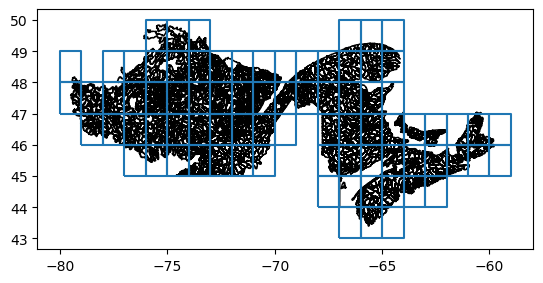

In [10]:
import geopandas as gpd
from shapely import Polygon
# f = "D:/ABDUBounds/ca_prov.parquet"
# df = gpd.read_parquet(f, filters=[["postal", "in", ['ON', 'NB', 'NL', 'NS', 'PE', 'QC']]])
df = gpd.read_parquet(params['hucsurl'])
df = df.to_crs(4326)
coords = df.geometry.get_coordinates()
polys = []
x = int(coords.x.min())-1
y = int(coords.y.min())-1
while y < int(coords.y.max())+1:
    poly = Polygon(((x, y),
        (x, y+1),
        (x+1, y+1),
        (x+1, y)
        ))
    if df.geometry.centroid.within(poly, align=False).any():
        polys.append(poly)
    x += 1
    if x == int(coords.x.max())+1:
        x = int(coords.x.min())-1
        y += 1
s = gpd.GeoSeries(polys,
        crs=4326)
print(len(s))
ax1 = df.plot(color='white', edgecolor='black')
s.boundary.plot(ax=ax1)

In [11]:
coords = s.to_crs(5070).get_coordinates()
listaoi = [coords.loc[i,:].values.tolist() for i in coords.index.unique()]
df = gpd.GeoDataFrame(dict(fname='', pcs5070=map(str,listaoi), geometry=s), crs=4326)
df.loc[:,'fname'] = df.geometry.centroid.apply(lambda pt: f"n{int(pt.y)}_e{int(pt.x)}".replace('e-','w').replace('n-','s'))
print(len(listaoi))
df.info()

81
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   fname     81 non-null     object  
 1   pcs5070   81 non-null     object  
 2   geometry  81 non-null     geometry
dtypes: geometry(1), object(2)
memory usage: 2.0+ KB


In [12]:
df.fname.is_unique, df.pcs5070.is_unique

(True, True)

In [13]:
def f(x):
    if isinstance(x, str):
        fname = x
    else:
        # pt = s.to_crs(4326).centroid[listaoi.index(x)]
        # fname = f"n{int(pt.y)}_e{int(pt.x)}".replace('e-','w').replace('n-','s')
        fname = df[df.pcs5070==str(x)].fname.values[0]
    try:         
        if os.path.isfile('./output/'+fname+'.parquet'):
            return (fname, 'exists')
        else:
            params['aoi'] = x
            subprocess.run(pm.execute_notebook(py_nb,'./output/{0}.ipynb'.format(fname),parameters=params), shell=True)
            return (fname, 'run complete')
    except Exception as e:
        if os.path.isfile('./output/'+fname+'.parquet'):
            return (fname, 'run complete')
        return (fname,'fail', e)

In [14]:
start_time = time.time()
print(time.ctime(start_time))

Tue Oct  7 10:52:51 2025


In [24]:
completed = Parallel(n_jobs=2, verbose=10)(delayed(f)(listaoi[x]) for x in range(len(listaoi)))

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed: 27.7min finished


In [16]:
print('Done in {0:.1f} seconds'.format(time.time() - start_time))

Done in 14049.8 seconds


In [18]:
len([i for i in completed if not i[1] == 'run complete'])
len([i for i in completed if not i[1] in ('run complete', 'exists')])
# [i for i in completed if not i[1] == 'run complete']

0

In [ ]:
#check for failed
completed
#fixme = completed

In [25]:
hucs = gpd.read_parquet(params['hucsurl'])[params['hucidfld']].to_list()
print(len(hucs))
n0 = 0; hucs_done = []
for i in os.listdir('./output/'):
    if i.endswith('.parquet') and i.startswith('n'):
        if n0==0:
            cols = gpd.read_parquet(f'./output/{i}').columns.to_list()
        n, c = gpd.read_parquet(f'./output/{i}').shape
        n0 += n
        hucs_done.extend(gpd.read_parquet(f'./output/{i}')[params['hucidfld']].to_list())
        print(i, (n,c), n0)
        print(set(cols) - set(gpd.read_parquet(f'./output/{i}').columns.to_list()))
        print()
    

2382
n43_w64.parquet (1, 87) 1
set()

n43_w65.parquet (22, 87) 23
set()

n43_w66.parquet (3, 87) 26
set()

n44_w62.parquet (11, 87) 37
set()

n44_w63.parquet (24, 87) 61
set()

n44_w64.parquet (30, 87) 91
set()

n44_w65.parquet (24, 87) 115
set()

n44_w66.parquet (13, 87) 128
set()

n44_w67.parquet (1, 87) 129
set()

n45_w59.parquet (2, 87) 131
set()

n45_w60.parquet (17, 87) 148
set()

n45_w61.parquet (40, 87) 188
set()

n45_w62.parquet (29, 87) 217
set()

n45_w63.parquet (37, 87) 254
set()

n45_w64.parquet (40, 87) 294
set()

n45_w65.parquet (26, 87) 320
set()

n45_w66.parquet (41, 87) 361
set()

n45_w67.parquet (28, 87) 389
set()

n45_w70.parquet (11, 87) 400
set()

n45_w71.parquet (38, 87) 438
set()

n45_w72.parquet (48, 87) 486
set()

n45_w73.parquet (60, 87) 546
set()

n45_w74.parquet (33, 87) 579
set()

n45_w75.parquet (13, 87) 592
set()

n45_w76.parquet (5, 87) 597
set()

n46_w59.parquet (3, 87) 600
set()

n46_w60.parquet (39, 87) 639
set()

n46_w61.parquet (9, 87) 648
set()

n

In [26]:
len(set(hucs) - set(hucs_done)),set(hucs) - set(hucs_done)

(0, set())

In [ ]:
#merge all parquet files in ./output/*.parquet
# if not 'duckdb' in locals().keys():
#     print('importing duckdb')
#     import duckdb
#     duckdb.load_extension("spatial")
# # fname = os.path.basename(params['hucsurl']).replace('.parquet', 'wH2Ocalc') #.rsplit('\\',1)[1]
# fname = 'abdu_cn_east_v2'
# print(fname)
# duckdb.execute(f"""
# COPY (SELECT * FROM './output/n*.parquet') TO './output/{fname}.parquet' (FORMAT 'parquet');
# """)

In [23]:
# listaoi = df[df.fname.isin(['n44_w76', 'n49_w95', 'n50_w95'])].geometry.to_crs(5070).bounds.values.tolist()
# listaoi = df[df.fname.isin(['n45_w61', 'n46_w61', 'n46_w60'])].geometry.to_crs(5070).bounds.values.tolist()
coords = df[df.fname.isin(['n47_w69','n49_w64'])].to_crs(5070).get_coordinates()
listaoi = [coords.loc[i,:].values.tolist() for i in coords.index.unique()]
listaoi

[[[1961903.5115299302, 2937754.5845952313],
  [1932055.6026493446, 3044117.308033371],
  [2004393.8441482105, 3064828.390723587],
  [2035359.3651220028, 2958785.3681315966],
  [1961903.5115299302, 2937754.5845952313]],
 [[2256179.192264037, 3259505.0832735235],
  [2221060.1946121375, 3363319.133820226],
  [2290023.754630873, 3387053.5349835064],
  [2326233.069136627, 3283614.4437254067],
  [2256179.192264037, 3259505.0832735235]]]

In [ ]:
for fname in df.fname:
    if os.path.isfile('./output/'+fname+'.ipynb'):
        print(fname, 'ipynb exists')
        if os.path.isfile('./output/'+fname+'.parquet'):
            print(fname, 'parquet exists')   
        else:
            os.remove(('./output/'+fname+'.ipynb'))
            print('removed ipynb')